In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

processed = Path("../data/processed")

runs = pd.read_csv(processed / "runs.csv", parse_dates=['date'])
streams = pd.read_csv(processed / "streams.csv", 
                      index_col='timestamp', parse_dates=True)

# Ensure consistent types for the join key
runs['file_stem'] = runs['file_stem'].astype(str)
streams['activity_id'] = streams['activity_id'].astype(str)

print(f"Runs:    {runs.shape}")
print(f"Streams: {streams.shape}")
print(f"\nRuns date range: {runs['date'].min().date()} → {runs['date'].max().date()}")
print(f"Streams activities: {streams['activity_id'].nunique()}")

Runs:    (211, 21)
Streams: (142103, 9)

Runs date range: 2022-04-29 → 2026-04-12
Streams activities: 207


In [3]:
def compute_hr_zones(hr_series, max_hr):
    """
    Given a series of HR values and the athlete's max HR,
    return fraction of time spent in each of 5 zones.
    
    Zone boundaries follow the standard 5-zone model:
    Z1 < 60%, Z2 60-70%, Z3 70-80%, Z4 80-90%, Z5 > 90%
    """
    hr = hr_series.dropna()
    if len(hr) == 0:
        return {f'hr_zone{i}_frac': np.nan for i in range(1, 6)}
    
    thresholds = [0, 0.60, 0.70, 0.80, 0.90, 1.01]
    zones = {}
    for i in range(1, 6):
        lo = thresholds[i-1] * max_hr
        hi = thresholds[i]   * max_hr
        zones[f'hr_zone{i}_frac'] = ((hr >= lo) & (hr < hi)).sum() / len(hr)
    return zones


def compute_within_run_features(group, max_hr):
    """
    Takes a DataFrame of per-second records for ONE activity.
    Returns a dict of scalar features.
    
    'group' has columns: pace_min_km, heart_rate, cadence,
                         enhanced_speed, enhanced_altitude, lat, lon
    """
    feats = {}

    # ── Pace features ────────────────────────────────────────────────────────
    # Only use rows where we're actually moving (pace not null)
    moving = group['pace_min_km'].dropna()

    feats['pace_mean']   = moving.mean()
    feats['pace_std']    = moving.std()
    # Coefficient of variation: std/mean — normalises variability by pace level
    # A slow runner and a fast runner can both have low CV if they're consistent
    # This is more meaningful than raw std for comparing across runs
    feats['pace_cv']     = feats['pace_std'] / feats['pace_mean'] if feats['pace_mean'] > 0 else np.nan
    feats['pace_p10']    = moving.quantile(0.10)   # fast tail (low pace = fast)
    feats['pace_p90']    = moving.quantile(0.90)   # slow tail

    # ── Heart rate features ───────────────────────────────────────────────────
    hr = group['heart_rate'].dropna()
    feats['hr_mean']          = hr.mean()
    feats['hr_std']           = hr.std()
    feats['hr_max_recorded']  = hr.max()
    # Fraction of activity with valid HR — data quality indicator
    feats['hr_coverage']      = len(hr) / len(group)

    # HR zones — time spent in each intensity band
    zones = compute_hr_zones(hr, max_hr)
    feats.update(zones)

    # ── Pace-HR coupling ─────────────────────────────────────────────────────
    # Aerobic decoupling: correlation between pace and HR over the run
    # In a well-paced aerobic run, HR should stay stable even as you fatigue
    # High decoupling (HR drifting up at constant pace) = early fatigue signal
    paired = group[['pace_min_km', 'heart_rate']].dropna()
    if len(paired) > 30:
        # We split the run in half and compare HR:pace ratio
        # This is a simplified version of TrainingPeaks' aerobic decoupling metric
        mid = len(paired) // 2
        first_half  = paired.iloc[:mid]
        second_half = paired.iloc[mid:]
        # HR:pace ratio — higher means working harder per unit pace
        ratio_first  = first_half['heart_rate'].mean()  / first_half['pace_min_km'].mean()
        ratio_second = second_half['heart_rate'].mean() / second_half['pace_min_km'].mean()
        feats['hr_pace_decoupling'] = (ratio_second - ratio_first) / ratio_first
    else:
        feats['hr_pace_decoupling'] = np.nan

    # ── Cadence features ─────────────────────────────────────────────────────
    cad = group['cadence'].dropna()
    if len(cad) > 10:
        feats['cadence_mean'] = cad.mean()
        feats['cadence_std']  = cad.std()
    else:
        feats['cadence_mean'] = np.nan
        feats['cadence_std']  = np.nan

    # ── Elevation features ────────────────────────────────────────────────────
    alt = group['enhanced_altitude'].dropna()
    if len(alt) > 10:
        # Compute gain from positive-only differences between consecutive points
        # (same logic as what Strava does — only count climbing, not total range)
        diffs = alt.diff().dropna()
        feats['elevation_gain_stream'] = diffs[diffs > 0].sum()
        feats['elevation_loss_stream'] = diffs[diffs < 0].abs().sum()
    else:
        feats['elevation_gain_stream'] = np.nan
        feats['elevation_loss_stream'] = np.nan

    # ── Duration and movement ─────────────────────────────────────────────────
    feats['duration_s']    = len(group)   # total records = total seconds recorded
    feats['moving_frac']   = (group['enhanced_speed'] > 0.5).sum() / len(group)

    return feats

In [4]:
# Derive max HR from your actual recorded data
# Use 98th percentile — not absolute max, which can be a sensor spike
max_hr_recorded = streams['heart_rate'].quantile(0.98)
max_hr = round(max_hr_recorded)

print(f"98th percentile HR from all your data: {max_hr_recorded:.1f}")
print(f"Using max HR: {max_hr} bpm")

# Sanity check — show the HR distribution
print(f"\nHR distribution:")
print(streams['heart_rate'].describe().round(1))

98th percentile HR from all your data: 176.0
Using max HR: 176 bpm

HR distribution:
count    121706.0
mean        146.6
std          17.2
min          58.0
25%         136.0
50%         148.0
75%         159.0
max         202.0
Name: heart_rate, dtype: float64


In [5]:
# Group streams by activity and apply our feature function
# tqdm wraps the groupby iterator so we get a progress bar

from tqdm import tqdm

within_run_rows = []

for activity_id, group in tqdm(streams.groupby('activity_id'), 
                                desc="Computing within-run features"):
    feats = compute_within_run_features(group, max_hr)
    feats['file_stem'] = activity_id
    within_run_rows.append(feats)

within_run_df = pd.DataFrame(within_run_rows)
print(f"Shape: {within_run_df.shape}")
print(f"\nFirst 3 rows (transposed for readability):")
print(within_run_df.head(3).T.to_string())

Computing within-run features: 100%|█████████████████████████████████████████████████| 207/207 [00:01<00:00, 110.29it/s]

Shape: (207, 22)

First 3 rows (transposed for readability):
                                 0            1            2
pace_mean                 5.940817     5.048473     5.079923
pace_std                  2.564011     1.548044     1.434814
pace_cv                   0.431592     0.306636     0.282448
pace_p10                   3.84976     4.238895     4.124012
pace_p90                  9.712527     5.351853     5.551368
hr_mean                 158.597452          NaN   165.509817
hr_std                   18.209558          NaN    13.697692
hr_max_recorded              202.0          NaN        186.0
hr_coverage                    1.0          0.0          1.0
hr_zone1_frac             0.011465          NaN     0.014895
hr_zone2_frac              0.03949          NaN     0.013541
hr_zone3_frac             0.093631          NaN     0.016926
hr_zone4_frac             0.318471          NaN      0.07109
hr_zone5_frac             0.376433          NaN     0.761679
hr_pace_decoupling      

In [6]:
print("Null rates (%):")
null_rates = (within_run_df.isna().sum() / len(within_run_df) * 100).round(1)
print(null_rates[null_rates > 0].to_string())  # only show columns with any nulls

Null rates (%):
hr_mean                   4.3
hr_std                    4.3
hr_max_recorded           4.3
hr_zone1_frac             4.3
hr_zone2_frac             4.3
hr_zone3_frac             4.3
hr_zone4_frac             4.3
hr_zone5_frac             4.3
hr_pace_decoupling        4.3
cadence_mean              6.8
cadence_std               6.8
elevation_gain_stream    17.9
elevation_loss_stream    17.9


In [7]:
# Columns we want from the summary CSV
# We're deliberately NOT including avg_speed_ms and grade_adj_distance
# because they're derived from the same underlying data as our other features
# (redundancy doesn't help models, it just adds noise)
summary_feats = runs[['file_stem', 'date', 'distance_km', 'moving_time_min',
                       'elevation_gain_m', 'hr_mean', 'hr_max',
                       'cadence_mean', 'avg_pace_min_km', 'relative_effort',
                       'calories']].copy()

# moving_ratio: how much of elapsed time was actual movement
# reveals walk breaks, long stops at traffic lights, etc.
summary_feats['moving_ratio'] = (
    runs['moving_time_s'] / runs['elapsed_time_s'].replace(0, np.nan)
)

print(summary_feats.shape)
print(summary_feats.head(3).T.to_string())
print(f"\nNull rates (%):")
print((summary_feats.isna().sum() / len(summary_feats) * 100).round(1))

(211, 12)
                                    0                    1                    2
file_stem                  7062035164           7146896280           9697773893
date              2022-04-29 23:49:01  2022-05-15 12:17:25  2023-08-22 10:33:07
distance_km                       6.8                 5.87                 10.5
moving_time_min                 44.05                 37.2            65.933333
elevation_gain_m                  3.2                  5.3                 21.4
hr_mean                           NaN                  NaN                  NaN
hr_max                            NaN                  NaN                  NaN
cadence_mean                      NaN                  NaN                  NaN
avg_pace_min_km              6.477523             6.329915               6.2751
relative_effort                   NaN                  NaN                  NaN
calories                        753.0                651.0               1242.0
moving_ratio                 0

In [8]:
# ── Build a daily load time series ───────────────────────────────────────────
# First, create a daily index spanning your full date range
date_min = runs['date'].min().normalize()  # midnight
date_max = runs['date'].max().normalize()
all_days = pd.date_range(date_min, date_max, freq='D')

# Daily distance — sum across all runs on the same day
# (you occasionally ran twice in one day based on the CSV)
daily = (runs.groupby(runs['date'].dt.normalize())['distance_km']
             .sum()
             .reindex(all_days, fill_value=0.0))

print(f"Daily series: {len(daily)} days")
print(f"Days with a run: {(daily > 0).sum()}")
print(f"Max daily distance: {daily.max():.1f} km")
print(f"\nSample (first 10 days with runs):")
print(daily[daily > 0].head(10))

Daily series: 1445 days
Days with a run: 198
Max daily distance: 25.1 km

Sample (first 10 days with runs):
2022-04-29     6.80
2022-05-15     5.87
2023-08-22    10.50
2023-08-23     6.72
2023-09-11     5.02
2023-09-20     5.22
2023-10-08     6.17
2023-10-21    10.20
2023-10-24     5.35
2023-10-26     5.44
Name: distance_km, dtype: float64


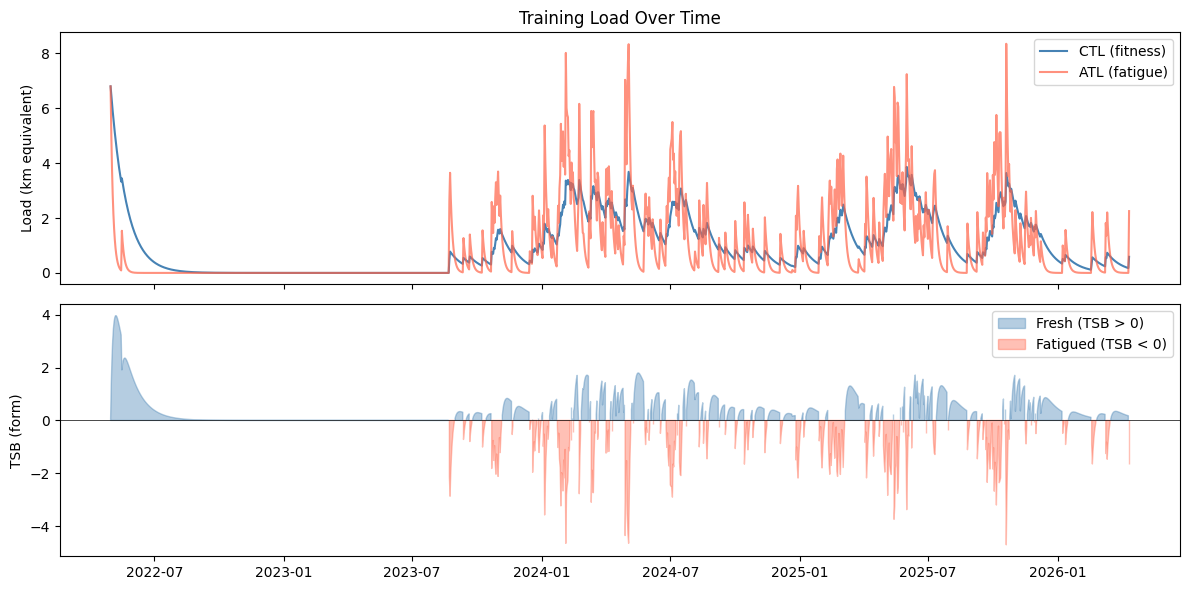

Plot saved.


In [11]:
# ── Compute ATL, CTL, TSB ─────────────────────────────────────────────────────
# pandas ewm() computes exponential weighted mean
# span=N means the weight decays such that N days ago has ~37% of today's weight
# This matches the standard Banister impulse-response model used in sports science

atl = daily.ewm(span=7,  adjust=False).mean()   # acute: 1-week memory
ctl = daily.ewm(span=42, adjust=False).mean()   # chronic: 6-week memory
tsb = ctl - atl                                  # form: positive = fresh

# ── Shift by 1 day — THE critical leakage prevention step ────────────────────
# We want "what was my fitness BEFORE today's run"
# Without shift(1), ATL on run day includes today's distance
# With shift(1), we use yesterday's value — information available before running
atl_lagged = atl.shift(1)
ctl_lagged = ctl.shift(1)
tsb_lagged = tsb.shift(1)

# Quick sanity plot — does CTL look like a fitness curve?
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(ctl_lagged.index, ctl_lagged.values, label='CTL (fitness)', color='steelblue')
axes[0].plot(atl_lagged.index, atl_lagged.values, label='ATL (fatigue)', color='tomato', alpha=0.7)
axes[0].set_ylabel('Load (km equivalent)')
axes[0].legend()
axes[0].set_title('Training Load Over Time')

axes[1].fill_between(tsb_lagged.index, tsb_lagged.values, 0,
                     where=tsb_lagged >= 0, color='steelblue', alpha=0.4, label='Fresh (TSB > 0)')
axes[1].fill_between(tsb_lagged.index, tsb_lagged.values, 0,
                     where=tsb_lagged < 0,  color='tomato',    alpha=0.4, label='Fatigued (TSB < 0)')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_ylabel('TSB (form)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/training_load.png', dpi=120)
plt.show()
print("Plot saved.")

In [12]:
# ── Map rolling features onto each run ───────────────────────────────────────
# For each run, look up the ATL/CTL/TSB value from the day before

def get_rolling_features(run_date, atl, ctl, tsb, daily):
    """
    Look up pre-run training load values for a given date.
    run_date: the date of the run
    Returns a dict of scalar load features.
    """
    day = run_date.normalize()  # strip time component → midnight

    feats = {}
    feats['atl_pre']  = atl_lagged.get(day, np.nan)
    feats['ctl_pre']  = ctl_lagged.get(day, np.nan)
    feats['tsb_pre']  = tsb_lagged.get(day, np.nan)

    # Weekly volume: total km in the 7 days before this run (not including today)
    week_start = day - pd.Timedelta(days=7)
    feats['weekly_km_7d'] = daily.loc[week_start:day - pd.Timedelta(days=1)].sum()

    # Number of runs in last 7 days
    feats['runs_7d'] = (daily.loc[week_start:day - pd.Timedelta(days=1)] > 0).sum()

    # Days since last run — rest/recovery indicator
    prior_runs = daily.loc[:day - pd.Timedelta(days=1)]
    last_run_days = prior_runs[prior_runs > 0]
    if len(last_run_days) > 0:
        feats['days_since_last_run'] = (day - last_run_days.index[-1]).days
    else:
        feats['days_since_last_run'] = np.nan  # first run ever

    # Week-over-week volume change
    prev_week_start = day - pd.Timedelta(days=14)
    prev_week_end   = day - pd.Timedelta(days=8)
    prev_weekly_km  = daily.loc[prev_week_start:prev_week_end].sum()
    if prev_weekly_km > 0:
        feats['weekly_km_delta_pct'] = (feats['weekly_km_7d'] - prev_weekly_km) / prev_weekly_km
    else:
        feats['weekly_km_delta_pct'] = np.nan

    return feats

# Apply to every run
rolling_rows = []
for _, row in runs.iterrows():
    feats = get_rolling_features(row['date'], atl_lagged, ctl_lagged, tsb_lagged, daily)
    feats['file_stem'] = str(row['file_stem'])
    rolling_rows.append(feats)

rolling_df = pd.DataFrame(rolling_rows)

print(f"Shape: {rolling_df.shape}")
print(f"\nSample:")
print(rolling_df.head(5).T.to_string())
print(f"\nNull rates (%):")
print((rolling_df.isna().sum() / len(rolling_df) * 100).round(1))

Shape: (211, 8)

Sample:
                              0           1           2           3           4
atl_pre                     NaN    0.090872         0.0       2.625    0.020571
ctl_pre                     NaN    3.328434         0.0    0.488372      0.3302
tsb_pre                     NaN    3.237562         0.0   -2.136628    0.309629
weekly_km_7d                0.0         0.0         0.0        10.5         0.0
runs_7d                       0           0           0           1           0
days_since_last_run         NaN        16.0       464.0         1.0        19.0
weekly_km_delta_pct         NaN         NaN         NaN         NaN         NaN
file_stem            7062035164  7146896280  9697773893  9704255381  9827502306

Null rates (%):
atl_pre                 0.5
ctl_pre                 0.5
tsb_pre                 0.5
weekly_km_7d            0.0
runs_7d                 0.0
days_since_last_run     0.5
weekly_km_delta_pct    20.4
file_stem               0.0
dtype: float64

In [13]:
# ── Join all three feature groups ─────────────────────────────────────────────
# Left join on file_stem — runs.csv is our master list (211 rows)
# within_run_df covers 207 (4 failed to parse — will get NaN for stream features)
# rolling_df covers all 211 (computed from dates, not files)

features = (
    summary_feats
    .merge(within_run_df, on='file_stem', how='left', suffixes=('_summary', '_stream'))
    .merge(rolling_df,    on='file_stem', how='left')
    .sort_values('date')
    .reset_index(drop=True)
)

print(f"Final feature table shape: {features.shape}")
print(f"\nColumn list:")
for col in features.columns:
    print(f"  {col}")

Final feature table shape: (211, 40)

Column list:
  file_stem
  date
  distance_km
  moving_time_min
  elevation_gain_m
  hr_mean_summary
  hr_max
  cadence_mean_summary
  avg_pace_min_km
  relative_effort
  calories
  moving_ratio
  pace_mean
  pace_std
  pace_cv
  pace_p10
  pace_p90
  hr_mean_stream
  hr_std
  hr_max_recorded
  hr_coverage
  hr_zone1_frac
  hr_zone2_frac
  hr_zone3_frac
  hr_zone4_frac
  hr_zone5_frac
  hr_pace_decoupling
  cadence_mean_stream
  cadence_std
  elevation_gain_stream
  elevation_loss_stream
  duration_s
  moving_frac
  atl_pre
  ctl_pre
  tsb_pre
  weekly_km_7d
  runs_7d
  days_since_last_run
  weekly_km_delta_pct


In [14]:
# ── Resolve duplicate columns ─────────────────────────────────────────────────

# HR mean: prefer stream (per-second average), fall back to summary CSV value
features['hr_mean'] = features['hr_mean_stream'].fillna(features['hr_mean_summary'])

# Cadence mean: same logic
features['cadence_mean'] = features['cadence_mean_stream'].fillna(features['cadence_mean_summary'])

# Elevation gain: stream version is more precise (computed from altimeter deltas)
# but summary version covers treadmill runs where stream has no GPS
# We'll keep both — they measure slightly different things
# elevation_gain_m = from CSV (Strava's calculation)
# elevation_gain_stream = from our altimeter delta calculation

# Drop the raw duplicates now that we've resolved them
features = features.drop(columns=[
    'hr_mean_summary', 'hr_mean_stream',
    'cadence_mean_summary', 'cadence_mean_stream',
])

# ── Also drop columns that are leaky or redundant ────────────────────────────
# moving_time_min and duration_s both measure run length — keep moving_time_min
# (from CSV, more reliable) and drop duration_s (count of stream records,
# affected by GPS dropout and recording gaps)
# 
# avg_pace_min_km from summary and pace_mean from streams are nearly identical
# Keep pace_mean (stream) — it's computed from actual second-by-second data
# Drop avg_pace_min_km (summary) — it's distance/time, ignores stops
features = features.drop(columns=['duration_s', 'avg_pace_min_km'])

print(f"Shape after pruning: {features.shape}")
print(f"\nFinal columns ({len(features.columns)}):")
for i, col in enumerate(features.columns):
    print(f"  {i+1:2d}. {col}")

Shape after pruning: (211, 36)

Final columns (36):
   1. file_stem
   2. date
   3. distance_km
   4. moving_time_min
   5. elevation_gain_m
   6. hr_max
   7. relative_effort
   8. calories
   9. moving_ratio
  10. pace_mean
  11. pace_std
  12. pace_cv
  13. pace_p10
  14. pace_p90
  15. hr_std
  16. hr_max_recorded
  17. hr_coverage
  18. hr_zone1_frac
  19. hr_zone2_frac
  20. hr_zone3_frac
  21. hr_zone4_frac
  22. hr_zone5_frac
  23. hr_pace_decoupling
  24. cadence_std
  25. elevation_gain_stream
  26. elevation_loss_stream
  27. moving_frac
  28. atl_pre
  29. ctl_pre
  30. tsb_pre
  31. weekly_km_7d
  32. runs_7d
  33. days_since_last_run
  34. weekly_km_delta_pct
  35. hr_mean
  36. cadence_mean


In [15]:
# ── Final null audit ──────────────────────────────────────────────────────────
print("Null rates (%) — final feature table:")
null_pct = (features.isna().sum() / len(features) * 100).round(1)
print(null_pct[null_pct > 0].to_string())

# How many rows are complete (no nulls at all)?
model_cols = [c for c in features.columns if c not in ['file_stem', 'date']]
complete = features[model_cols].dropna().shape[0]
print(f"\nCompletely null-free rows: {complete} / {len(features)}")

Null rates (%) — final feature table:
hr_max                    6.2
relative_effort           6.2
pace_mean                 1.9
pace_std                  1.9
pace_cv                   1.9
pace_p10                  1.9
pace_p90                  1.9
hr_std                    6.2
hr_max_recorded           6.2
hr_coverage               1.9
hr_zone1_frac             6.2
hr_zone2_frac             6.2
hr_zone3_frac             6.2
hr_zone4_frac             6.2
hr_zone5_frac             6.2
hr_pace_decoupling        6.2
cadence_std               8.5
elevation_gain_stream    19.4
elevation_loss_stream    19.4
moving_frac               1.9
atl_pre                   0.5
ctl_pre                   0.5
tsb_pre                   0.5
days_since_last_run       0.5
weekly_km_delta_pct      20.4
hr_mean                   6.2
cadence_mean              8.5

Completely null-free rows: 128 / 211


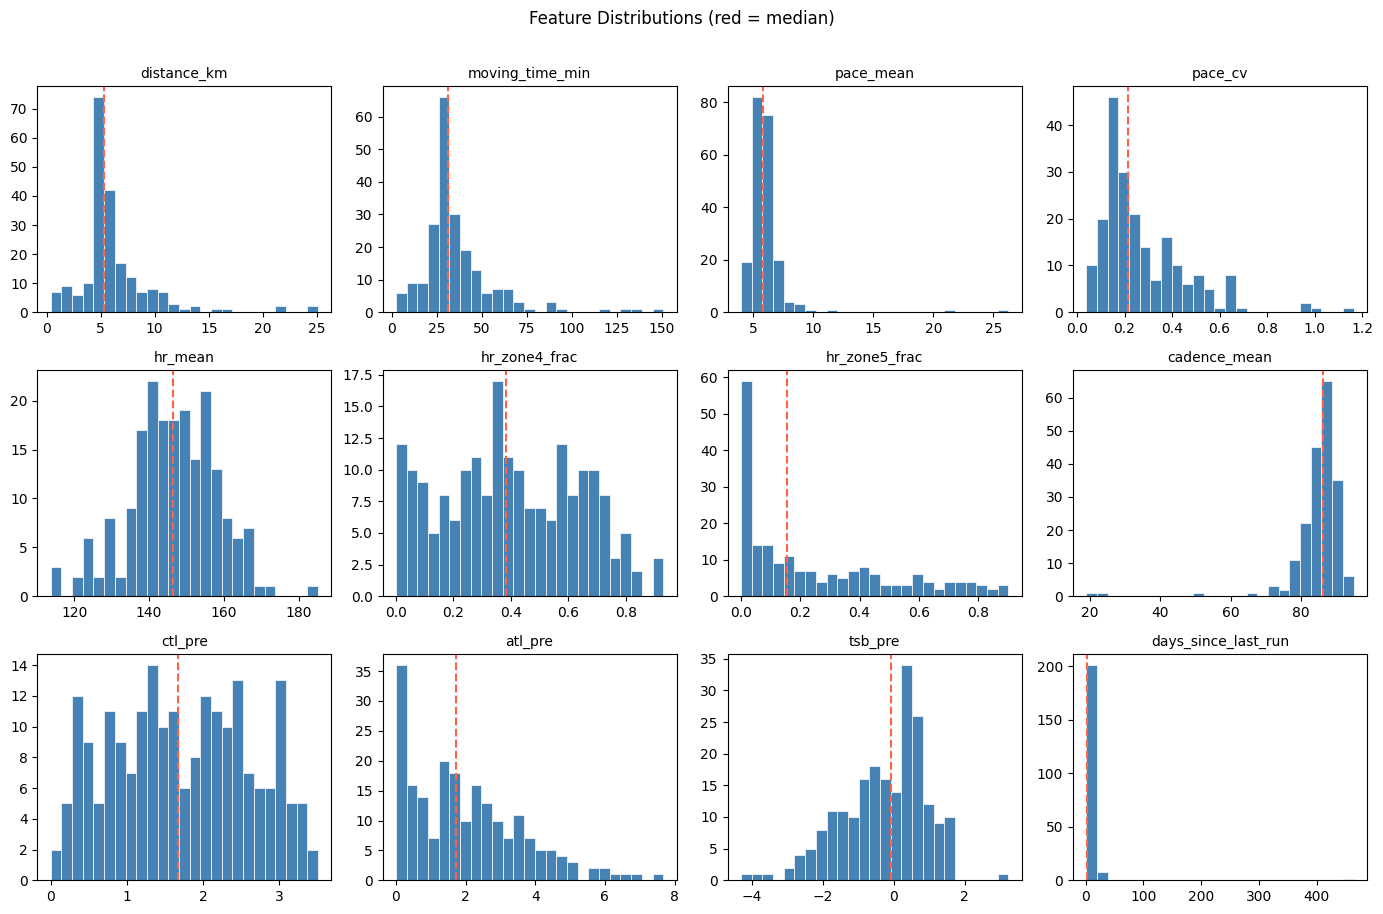

In [16]:
# ── Quick distributions check ─────────────────────────────────────────────────
# Plot the key continuous features to catch anything obviously wrong
# (outliers, wrong units, bimodal distributions that suggest parsing bugs)

key_features = ['distance_km', 'moving_time_min', 'pace_mean', 'pace_cv',
                'hr_mean', 'hr_zone4_frac', 'hr_zone5_frac',
                'cadence_mean', 'ctl_pre', 'atl_pre', 'tsb_pre',
                'days_since_last_run']

fig, axes = plt.subplots(3, 4, figsize=(14, 9))
axes = axes.flatten()

for i, col in enumerate(key_features):
    data = features[col].dropna()
    axes[i].hist(data, bins=25, color='steelblue', edgecolor='white', linewidth=0.5)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    # Add median line
    axes[i].axvline(data.median(), color='tomato', linewidth=1.5, linestyle='--')

plt.suptitle('Feature Distributions (red = median)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('../data/processed/feature_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

In [17]:
# ── Save ─────────────────────────────────────────────────────────────────────
features.to_csv('../data/processed/features.csv', index=False)
print(f"Saved features.csv — {features.shape[0]} rows × {features.shape[1]} columns")

Saved features.csv — 211 rows × 36 columns


In [18]:
# Which runs have the most nulls, and why?
model_cols = [c for c in features.columns if c not in ['file_stem', 'date']]
features['null_count'] = features[model_cols].isna().sum(axis=1)

print("Null count distribution:")
print(features['null_count'].value_counts().sort_index().to_string())

print("\nRuns with most nulls (top 10):")
worst = (features[['date','distance_km','moving_time_min','null_count',
                    'hr_mean','cadence_mean','elevation_gain_stream']]
         .sort_values('null_count', ascending=False)
         .head(10))
print(worst.to_string())

Null count distribution:
null_count
0     128
1      28
2      38
3       4
14      8
18      1
22      2
23      2

Runs with most nulls (top 10):
                  date  distance_km  moving_time_min  null_count  hr_mean  cadence_mean  elevation_gain_stream
6  2023-10-08 13:37:24         6.17        37.433333          23      NaN           NaN                    NaN
9  2023-10-24 13:14:24         5.35        31.583333          23      NaN           NaN                    NaN
8  2023-10-21 18:41:22         5.12        35.516667          22      NaN           NaN                    NaN
5  2023-09-20 12:45:16         5.22        29.733333          22      NaN           NaN                    NaN
0  2022-04-29 23:49:01         6.80        44.050000          18      NaN           NaN                   15.1
2  2023-08-22 10:33:07        10.50        65.933333          14      NaN           NaN                   33.4
1  2022-05-15 12:17:25         5.87        37.200000          14      NaN  

In [19]:
# Flag rather than drop — we want the model to see all 211 runs
# Tree models handle NaN natively (XGBoost, LightGBM)
# For sklearn models we'll impute at training time, not here
# Add a flag column for "has full sensor data" — useful as a feature itself
features['has_hr']      = features['hr_mean'].notna().astype(int)
features['has_cadence'] = features['cadence_mean'].notna().astype(int)
features['has_gps']     = features['elevation_gain_stream'].notna().astype(int)

# Drop the diagnostic null_count column before saving
features = features.drop(columns=['null_count'])

# Save
features.to_csv('../data/processed/features.csv', index=False)
print(f"Saved: {features.shape[0]} rows × {features.shape[1]} columns")
print(f"\nFinal column count: {len(features.columns)}")

Saved: 211 rows × 39 columns

Final column count: 39


In [20]:
# Final save confirmation
print("Phase 2 complete.")
print(f"\nfeatures.csv: {features.shape[0]} rows × {features.shape[1]} columns")
print(f"\nData coverage by sensor:")
print(f"  Full sensor data (0 nulls):     {(features['null_count_check'] if 'null_count_check' in features.columns else features[model_cols].isna().sum(axis=1) == 0).sum()} / {len(features)} runs")
print(f"  Has HR:      {features['has_hr'].sum()} / {len(features)}")
print(f"  Has cadence: {features['has_cadence'].sum()} / {len(features)}")  
print(f"  Has GPS:     {features['has_gps'].sum()} / {len(features)}")

# Quick summary of what we built
print(f"""
Feature groups:
  Summary features:      distance, time, elevation, pace, calories, moving_ratio
  Within-run (streams):  pace stats, HR zones, decoupling, cadence, elevation deltas  
  Rolling load:          ATL, CTL, TSB, weekly volume, rest days
  Data quality flags:    has_hr, has_cadence, has_gps
""")

Phase 2 complete.

features.csv: 211 rows × 39 columns

Data coverage by sensor:
  Full sensor data (0 nulls):     128 / 211 runs
  Has HR:      198 / 211
  Has cadence: 193 / 211
  Has GPS:     170 / 211

Feature groups:
  Summary features:      distance, time, elevation, pace, calories, moving_ratio
  Within-run (streams):  pace stats, HR zones, decoupling, cadence, elevation deltas  
  Rolling load:          ATL, CTL, TSB, weekly volume, rest days
  Data quality flags:    has_hr, has_cadence, has_gps

